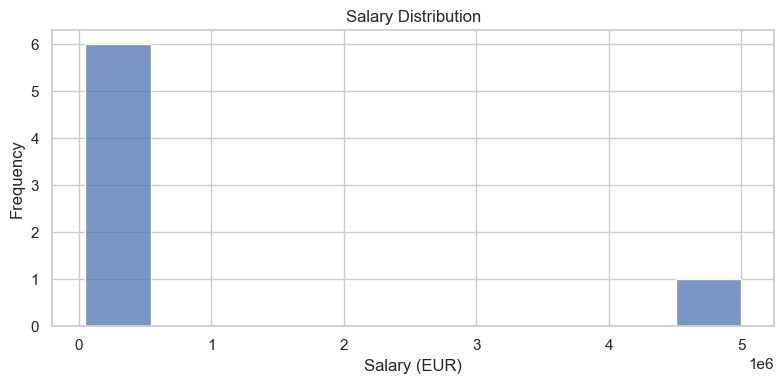

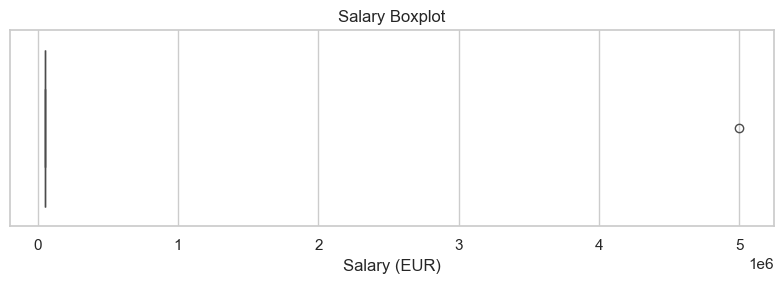

    metric         value
0     mean  7.592857e+05
1   median  5.300000e+04
2      min  5.000000e+04
3      max  5.000000e+06
4  std_dev  1.869980e+06


,employee_id,salary_eur
0,A,50000
1,B,52000
2,C,53000
3,D,54000
4,E,55000
5,F,51000
6,Executive,5000000


In [56]:
# ============================================================
# Section: Simple salary example
# When to use:
# - to explain mean vs median
# - to explain how one extreme value can distort averages
# - to discuss why segmenting can be better than deleting
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

salary_df = pd.DataFrame({
    "employee_id": ["A", "B", "C", "D", "E", "F", "Executive"],
    "salary_eur": [50000, 52000, 53000, 54000, 55000, 51000, 5_000_000]
})

salary_summary_df = pd.DataFrame({
    "metric": ["mean", "median", "min", "max", "std_dev"],
    "value": [
        salary_df["salary_eur"].mean(),
        salary_df["salary_eur"].median(),
        salary_df["salary_eur"].min(),
        salary_df["salary_eur"].max(),
        salary_df["salary_eur"].std()
    ]
})

plt.figure(figsize=(8, 4))
sns.histplot(data=salary_df, x="salary_eur", bins=10)
plt.title("Salary Distribution")
plt.xlabel("Salary (EUR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(data=salary_df, x="salary_eur")
plt.title("Salary Boxplot")
plt.xlabel("Salary (EUR)")
plt.tight_layout()
plt.show()

print(salary_summary_df)
salary_df



In [57]:
# ============================================================
# Section: Domain-rule detection
# When to use:
# - when business logic is clear
# - when impossible values exist
# - usually the best first step
# Example:
# - negative age
# - exam score above 100
# - impossible temperature
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

sensor_df = pd.DataFrame({
    "reading_id": range(1, 11),
    "temperature_c": [22, 23, 21, 24, 22, 23, 21, 22, 23, -50]
})

sensor_df["flag_domain_rule"] = (
    (sensor_df["temperature_c"] < -10) |
    (sensor_df["temperature_c"] > 60)
)

sensor_df




,reading_id,temperature_c,flag_domain_rule
0,1,22,False
1,2,23,False
2,3,21,False
3,4,24,False
4,5,22,False
5,6,23,False
6,7,21,False
7,8,22,False
8,9,23,False
9,10,-50,True


In [58]:
# ============================================================
# Section: Z-score detection
# When to use:
# - simple numeric outlier detection
# - first statistical screening
# Good for:
# - classroom examples
# - simple reports
# Limitation:
# - mean and std can be distorted by extreme skewness
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import zscore

np.random.seed(42)

zscore_df = sensor_df.copy()
zscore_df["temperature_zscore"] = zscore(zscore_df["temperature_c"], nan_policy="omit")
zscore_df["flag_zscore_2s"] = zscore_df["temperature_zscore"].abs() > 2
zscore_df["flag_zscore_3s"] = zscore_df["temperature_zscore"].abs() > 3

zscore_df




,reading_id,temperature_c,flag_domain_rule,temperature_zscore,flag_zscore_2s,flag_zscore_3s
0,1,22,False,0.317703,False,False
1,2,23,False,0.363746,False,False
2,3,21,False,0.271659,False,False
3,4,24,False,0.409790,False,False
4,5,22,False,0.317703,False,False
5,6,23,False,0.363746,False,False
6,7,21,False,0.271659,False,False
7,8,22,False,0.317703,False,False
8,9,23,False,0.363746,False,False
9,10,-50,True,-2.997455,True,False


In [59]:
# ============================================================
# Section: IQR detection
# When to use:
# - robust univariate outlier detection
# - when skewness exists
# - when you do not want to rely too much on the mean
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

iqr_df = salary_df.copy()

q1 = iqr_df["salary_eur"].quantile(0.25)
q3 = iqr_df["salary_eur"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_df["iqr_lower_bound"] = lower_bound
iqr_df["iqr_upper_bound"] = upper_bound
iqr_df["flag_iqr"] = (
    (iqr_df["salary_eur"] < lower_bound) |
    (iqr_df["salary_eur"] > upper_bound)
)

iqr_df




,employee_id,salary_eur,iqr_lower_bound,iqr_upper_bound,flag_iqr
0,A,50000,47000.0,59000.0,False
1,B,52000,47000.0,59000.0,False
2,C,53000,47000.0,59000.0,False
3,D,54000,47000.0,59000.0,False
4,E,55000,47000.0,59000.0,False
5,F,51000,47000.0,59000.0,False
6,Executive,5000000,47000.0,59000.0,True


In [60]:
# ============================================================
# Section: Capping as treatment
# When to use:
# - values are real but too extreme for a model
# - you want to reduce distortion without deleting rows
# Also called:
# - capping
# - simple winsorization-style treatment
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

capped_df = salary_df.copy()
upper_cap = capped_df["salary_eur"].quantile(0.95)

capped_df["salary_capped"] = np.minimum(capped_df["salary_eur"], upper_cap)

capped_df




,employee_id,salary_eur,salary_capped
0,A,50000,50000.0
1,B,52000,52000.0
2,C,53000,53000.0
3,D,54000,54000.0
4,E,55000,55000.0
5,F,51000,51000.0
6,Executive,5000000,3516500.0


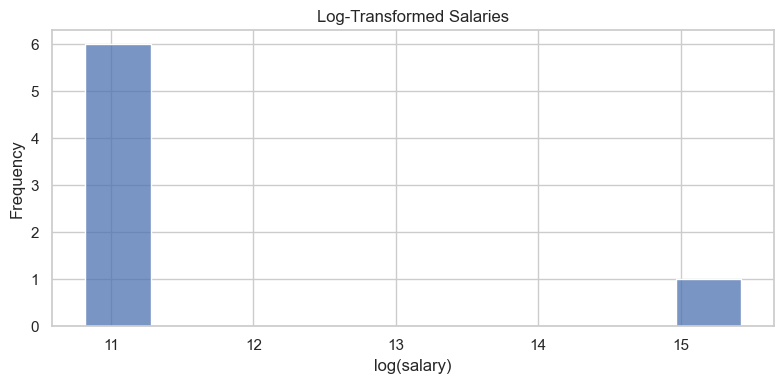

,employee_id,salary_eur,salary_log
0,A,50000,10.819778
1,B,52000,10.858999
2,C,53000,10.878047
3,D,54000,10.896739
4,E,55000,10.915088
5,F,51000,10.839581
6,Executive,5000000,15.424948


In [61]:
# ============================================================
# Section: Log transformation
# When to use:
# - data is strongly right-skewed
# - values are strictly positive
# - you want to reduce skewness
# Good examples:
# - income
# - transaction amount
# - revenue
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

log_df = salary_df.copy()
log_df["salary_log"] = np.log(log_df["salary_eur"])

plt.figure(figsize=(8, 4))
sns.histplot(data=log_df, x="salary_log", bins=10)
plt.title("Log-Transformed Salaries")
plt.xlabel("log(salary)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

log_df[["employee_id", "salary_eur", "salary_log"]]




In [62]:
# ============================================================
# Section: Mean imputation
# When to use:
# - simple teaching example
# - non-time-series data
# Limitation:
# - may ignore local patterns
# - often too simplistic for real operational data
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

mean_impute_df = sensor_df.copy()
mean_value = mean_impute_df.loc[~mean_impute_df["flag_domain_rule"], "temperature_c"].mean()

# Use float dtype so assigning a non-integer mean is valid in recent pandas versions.
mean_impute_df["temperature_imputed_mean"] = mean_impute_df["temperature_c"].astype(float)
mean_impute_df.loc[mean_impute_df["flag_domain_rule"], "temperature_imputed_mean"] = mean_value

mean_impute_df


,reading_id,temperature_c,flag_domain_rule,temperature_imputed_mean
0,1,22,False,22.000000
1,2,23,False,23.000000
2,3,21,False,21.000000
3,4,24,False,24.000000
4,5,22,False,22.000000
5,6,23,False,23.000000
6,7,21,False,21.000000
7,8,22,False,22.000000
8,9,23,False,23.000000
9,10,-50,True,22.333333


In [63]:
# ============================================================
# Section: Median imputation
# When to use:
# - simple replacement
# - more robust than mean when skewness exists
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

median_impute_df = sensor_df.copy()
median_value = median_impute_df.loc[~median_impute_df["flag_domain_rule"], "temperature_c"].median()

median_impute_df["temperature_imputed_median"] = median_impute_df["temperature_c"]
median_impute_df.loc[median_impute_df["flag_domain_rule"], "temperature_imputed_median"] = median_value

median_impute_df




,reading_id,temperature_c,flag_domain_rule,temperature_imputed_median
0,1,22,False,22
1,2,23,False,23
2,3,21,False,21
3,4,24,False,24
4,5,22,False,22
5,6,23,False,23
6,7,21,False,21
7,8,22,False,22
8,9,23,False,23
9,10,-50,True,22


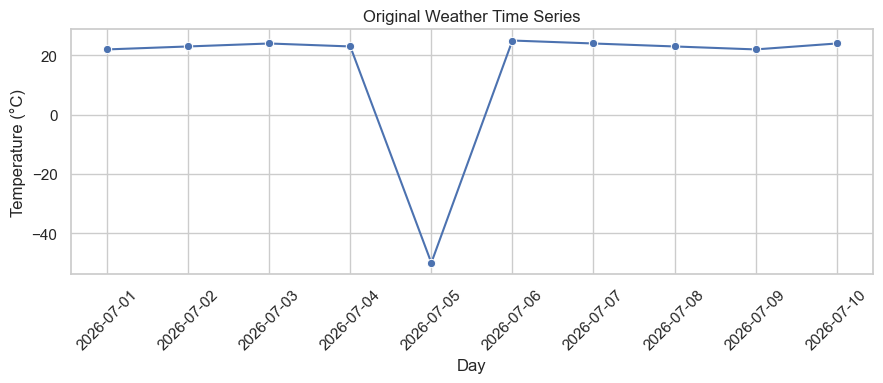

,day,temperature_c,flag_domain_rule
0,2026-07-01,22,False
1,2026-07-02,23,False
2,2026-07-03,24,False
3,2026-07-04,23,False
4,2026-07-05,-50,True
5,2026-07-06,25,False
6,2026-07-07,24,False
7,2026-07-08,23,False
8,2026-07-09,22,False
9,2026-07-10,24,False


In [64]:
# ============================================================
# Section: Weather time-series example
# When to use:
# - ordered data over time
# - local continuity is expected
# - a value is very likely a local error
# This is one of the strongest examples for imputation.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

weather_df = pd.DataFrame({
    "day": pd.date_range("2026-07-01", periods=10, freq="D"),
    "temperature_c": [22, 23, 24, 23, -50, 25, 24, 23, 22, 24]
})

weather_df["flag_domain_rule"] = (
    (weather_df["temperature_c"] < 0) |
    (weather_df["temperature_c"] > 45)
)

plt.figure(figsize=(9, 4))
sns.lineplot(data=weather_df, x="day", y="temperature_c", marker="o")
plt.title("Original Weather Time Series")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

weather_df




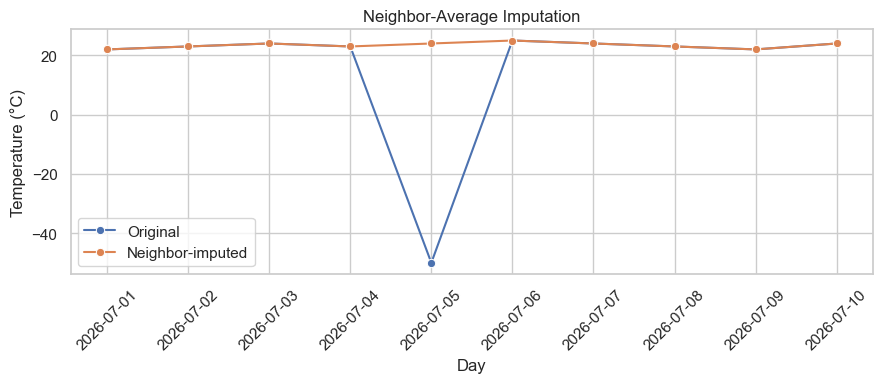

,day,temperature_c,flag_domain_rule,temperature_neighbor_imputed
0,2026-07-01,22,False,22.0
1,2026-07-02,23,False,23.0
2,2026-07-03,24,False,24.0
3,2026-07-04,23,False,23.0
4,2026-07-05,-50,True,24.0
5,2026-07-06,25,False,25.0
6,2026-07-07,24,False,24.0
7,2026-07-08,23,False,23.0
8,2026-07-09,22,False,22.0
9,2026-07-10,24,False,24.0


In [65]:
# ============================================================
# Section: Neighbor-average imputation
# When to use:
# - time series
# - clearly wrong local spike
# Example:
# 22, -50, 24  --> 23
# This often makes more sense than replacing with the overall mean.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

neighbor_df = weather_df.copy()
neighbor_df["temperature_neighbor_imputed"] = neighbor_df["temperature_c"].astype(float)

flagged_indices = neighbor_df.index[neighbor_df["flag_domain_rule"]].tolist()

for idx in flagged_indices:
    prev_value = np.nan
    next_value = np.nan

    if idx - 1 in neighbor_df.index:
        prev_value = neighbor_df.loc[idx - 1, "temperature_neighbor_imputed"]
    if idx + 1 in neighbor_df.index:
        next_value = neighbor_df.loc[idx + 1, "temperature_neighbor_imputed"]

    if pd.notna(prev_value) and pd.notna(next_value):
        neighbor_df.loc[idx, "temperature_neighbor_imputed"] = (prev_value + next_value) / 2
    elif pd.notna(prev_value):
        neighbor_df.loc[idx, "temperature_neighbor_imputed"] = prev_value
    elif pd.notna(next_value):
        neighbor_df.loc[idx, "temperature_neighbor_imputed"] = next_value

plt.figure(figsize=(9, 4))
sns.lineplot(data=neighbor_df, x="day", y="temperature_c", marker="o", label="Original")
sns.lineplot(data=neighbor_df, x="day", y="temperature_neighbor_imputed", marker="o", label="Neighbor-imputed")
plt.title("Neighbor-Average Imputation")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

neighbor_df




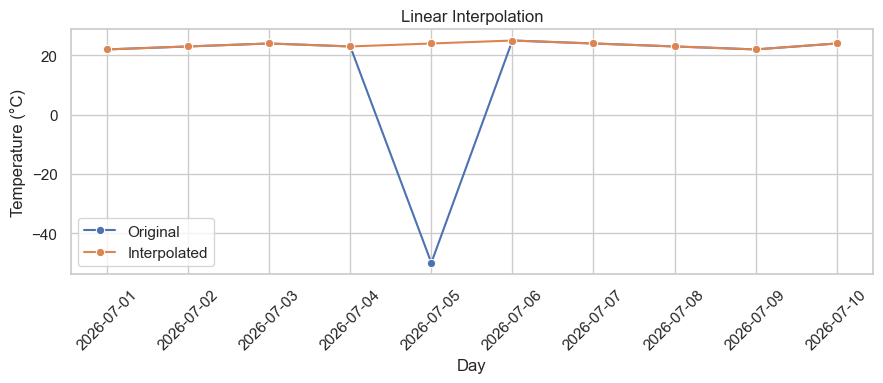

,day,temperature_c,flag_domain_rule,temperature_for_interpolation,temperature_interpolated
0,2026-07-01,22,False,22.0,22.0
1,2026-07-02,23,False,23.0,23.0
2,2026-07-03,24,False,24.0,24.0
3,2026-07-04,23,False,23.0,23.0
4,2026-07-05,-50,True,NaN,24.0
5,2026-07-06,25,False,25.0,25.0
6,2026-07-07,24,False,24.0,24.0
7,2026-07-08,23,False,23.0,23.0
8,2026-07-09,22,False,22.0,22.0
9,2026-07-10,24,False,24.0,24.0


In [66]:
# ============================================================
# Section: Linear interpolation
# When to use:
# - time series
# - ordered observations
# - smooth transitions expected
# This is a more professional wording than simply 'replace with the mean'.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

interp_df = weather_df.copy()
interp_df["temperature_for_interpolation"] = interp_df["temperature_c"].astype(float)
interp_df.loc[interp_df["flag_domain_rule"], "temperature_for_interpolation"] = np.nan
interp_df["temperature_interpolated"] = interp_df["temperature_for_interpolation"].interpolate(method="linear")

plt.figure(figsize=(9, 4))
sns.lineplot(data=interp_df, x="day", y="temperature_c", marker="o", label="Original")
sns.lineplot(data=interp_df, x="day", y="temperature_interpolated", marker="o", label="Interpolated")
plt.title("Linear Interpolation")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

interp_df




In [67]:
# ============================================================
# Section: Removing flagged rows
# When to use:
# - removal is justified
# - decision is documented
# - business context supports it
# Warning:
# - do not remove rows blindly
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

removed_df = weather_df.loc[~weather_df["flag_domain_rule"]].copy()

removed_df




,day,temperature_c,flag_domain_rule
0,2026-07-01,22,False
1,2026-07-02,23,False
2,2026-07-03,24,False
3,2026-07-04,23,False
5,2026-07-06,25,False
6,2026-07-07,24,False
7,2026-07-08,23,False
8,2026-07-09,22,False
9,2026-07-10,24,False


In [68]:
# ============================================================
# Section: Open-source dataset for advanced methods
# Dataset:
# - Breast Cancer Wisconsin dataset
# Why use it:
# - open and common
# - many numeric variables
# - good for multivariate outlier methods
# ============================================================

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

X.head()




,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


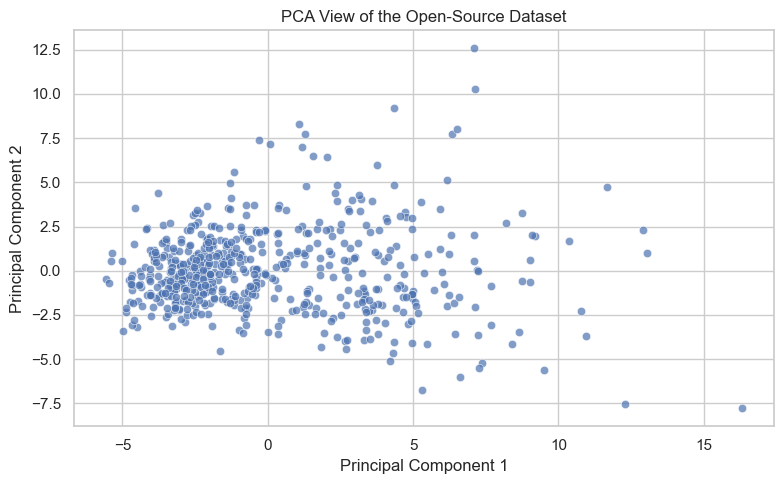

,pc1,pc2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


In [ ]:
# ============================================================
# Section: PCA visualization
# When to use:
# - many numeric variables
# - you want a visual overview
# - you want to work with multivariate structure
# PCA is for visualization here, not final outlier decision by itself.
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "pc1": components[:, 0],
    "pc2": components[:, 1]
})

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", alpha=0.7)
plt.title("PCA View of the Open-Source Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

pca_df.head()




In [70]:
# ============================================================
# Section: Isolation Forest
# When to use:
# - many numeric variables
# - practical modern anomaly detection
# Intuition:
# - unusual points are easier to isolate
# ============================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

np.random.seed(42)

iso_model = IsolationForest(contamination=0.03, random_state=42)
iso_labels = iso_model.fit_predict(X)

iso_df = X.copy()
iso_df["isolation_forest_label"] = iso_labels
iso_df["isolation_forest_flag"] = iso_df["isolation_forest_label"] == -1
iso_df["isolation_forest_score"] = iso_model.decision_function(X)

iso_df[["isolation_forest_label", "isolation_forest_flag", "isolation_forest_score"]].head()




,isolation_forest_label,isolation_forest_flag,isolation_forest_score
0,-1,True,-0.000128
1,1,False,0.125307
2,1,False,0.123151
3,-1,True,-0.072184
4,1,False,0.116831


In [71]:
# ============================================================
# Section: LOF (Local Outlier Factor)
# When to use:
# - local density matters
# - clusters may exist
# Intuition:
# - a point may look normal globally but strange relative to neighbors
# ============================================================

import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
lof_labels = lof_model.fit_predict(X)

lof_df = X.copy()
lof_df["lof_label"] = lof_labels
lof_df["lof_flag"] = lof_df["lof_label"] == -1
lof_df["lof_score"] = lof_model.negative_outlier_factor_

lof_df[["lof_label", "lof_flag", "lof_score"]].head()




,lof_label,lof_flag,lof_score
0,1,False,-1.422440
1,1,False,-1.066782
2,1,False,-0.978948
3,1,False,-1.596933
4,1,False,-1.069936


In [72]:
# ============================================================
# Section: Mahalanobis distance
# When to use:
# - multivariate numeric data
# - you want a classical method
# Intuition:
# - a value may not be extreme in one variable,
#   but may be unusual in combination with others
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

np.random.seed(42)

X_num = X.select_dtypes(include=[np.number]).copy()

mean_vec = X_num.mean().values
cov_matrix = np.cov(X_num.values, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)

mahalanobis_distances = []

for _, row in X_num.iterrows():
    dist = mahalanobis(row.values, mean_vec, inv_cov_matrix)
    mahalanobis_distances.append(dist)

maha_df = X.copy()
maha_df["mahalanobis_distance"] = mahalanobis_distances
threshold = maha_df["mahalanobis_distance"].quantile(0.97)
maha_df["mahalanobis_flag"] = maha_df["mahalanobis_distance"] > threshold

maha_df[["mahalanobis_distance", "mahalanobis_flag"]].head()




,mahalanobis_distance,mahalanobis_flag
0,9.614905,False
1,6.027952,False
2,4.854151,False
3,10.591878,False
4,5.176268,False


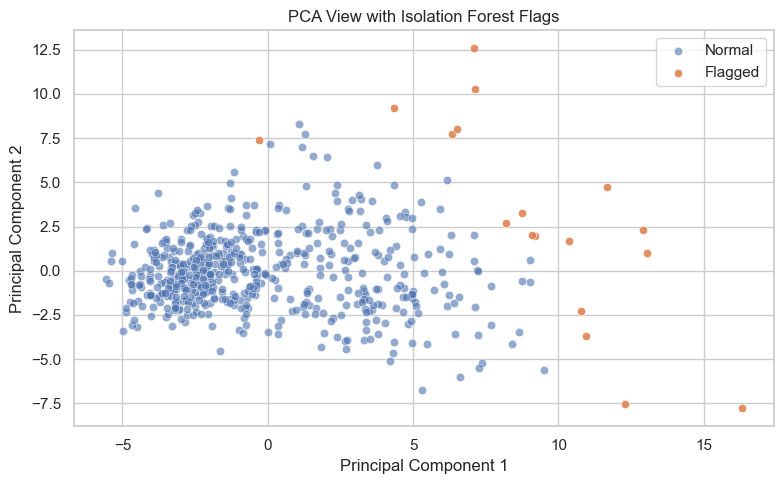

,pc1,pc2,flag
0,9.192837,1.948583,True
1,2.387802,-3.768172,False
2,5.733896,-1.075174,False
3,7.122953,10.275589,True
4,3.935302,-1.948072,False


In [73]:
# ============================================================
# Section: PCA with Isolation Forest flags
# When to use:
# - to visualize advanced outlier detection results
# - to compare flagged vs non-flagged observations
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(42)

X_scaled_again = StandardScaler().fit_transform(X)
pca_again = PCA(n_components=2, random_state=42)
components_again = pca_again.fit_transform(X_scaled_again)

plot_df = pd.DataFrame({
    "pc1": components_again[:, 0],
    "pc2": components_again[:, 1],
    "flag": iso_df["isolation_forest_flag"].values
})

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df.loc[~plot_df["flag"]],
    x="pc1",
    y="pc2",
    alpha=0.6,
    label="Normal"
)

sns.scatterplot(
    data=plot_df.loc[plot_df["flag"]],
    x="pc1",
    y="pc2",
    alpha=0.9,
    label="Flagged"
)

plt.title("PCA View with Isolation Forest Flags")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

plot_df.head()




In [ ]:
# ============================================================
# Section: Simple method-selection guide
# When to use:
# - as a quick cheat sheet 
# - at the end of the notebook
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

method_guide = pd.DataFrame({
    "Method": [
        "Domain Rules",
        "Z-Score",
        "IQR Rule",
        "Capping",
        "Log Transform",
        "Mean / Median Imputation",
        "Neighbor Average / Interpolation",
        "Isolation Forest",
        "LOF",
        "Mahalanobis Distance",
        "PCA Visualization"
    ],
    "Best For": [
        "Impossible or rule-based values",
        "Simple numeric screening",
        "Robust univariate screening",
        "Reduce influence of extremes",
        "Reduce right skewness",
        "Simple replacement of bad values",
        "Time-series error treatment",
        "Many numeric variables",
        "Local density anomalies",
        "Strange variable combinations",
        "Visual multivariate intuition"
    ],
    "Simple Message": [
        "Use business logic first.",
        "Good first statistical method.",
        "Good when skewness exists.",
        "Keep rows but limit distortion.",
        "Useful for positive right-skewed variables.",
        "Simple but may ignore local context.",
        "Great for weather and sensor time series.",
        "Modern and practical.",
        "Useful when clusters matter.",
        "Classical multivariate method.",
        "Best for visual understanding."
    ]
})

method_guide


,Method,Best For,Simple Message
0,Domain Rules,Impossible or rule-based values,Use business logic first.
1,Z-Score,Simple numeric screening,Good first statistical method.
2,IQR Rule,Robust univariate screening,Good when skewness exists.
3,Capping,Reduce influence of extremes,Keep rows but limit distortion.
4,Log Transform,Reduce right skewness,Useful for positive right-skewed variables.
5,Mean / Median Imputation,Simple replacement of bad values,Simple but may ignore local context.
6,Neighbor Average / Interpolation,Time-series error treatment,Great for weather and sensor time series.
7,Isolation Forest,Many numeric variables,Modern and practical.
8,LOF,Local density anomalies,Useful when clusters matter.
9,Mahalanobis Distance,Strange variable combinations,Classical multivariate method.
